In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('real-year_csv.csv')

# print(df.head()) # print 5 baris teratas
# print()
# print(df.info()) # info like struktur ringkas data satu csv itu
# print()
# print(df.describe())

df['date'] = pd.to_datetime(df['date'])
df_clean = df.dropna(subset=['price'])

print("Ukuran data setelah dibersihkan: ", df_clean.shape)
print()
print("Statistik dataset sekarang: ", df_clean.describe())

Ukuran data setelah dibersihkan:  (4317, 3)

Statistik dataset sekarang:                               date        price
count                        4317  4317.000000
mean   2005-02-09 03:04:47.699791     2.056407
min           1967-03-31 00:00:00   -45.840000
25%           2000-03-31 00:00:00    -2.350000
50%           2008-06-30 00:00:00     1.720000
75%           2013-03-31 00:00:00     6.230000
max           2017-09-30 00:00:00    59.580000
std                           NaN     8.878045


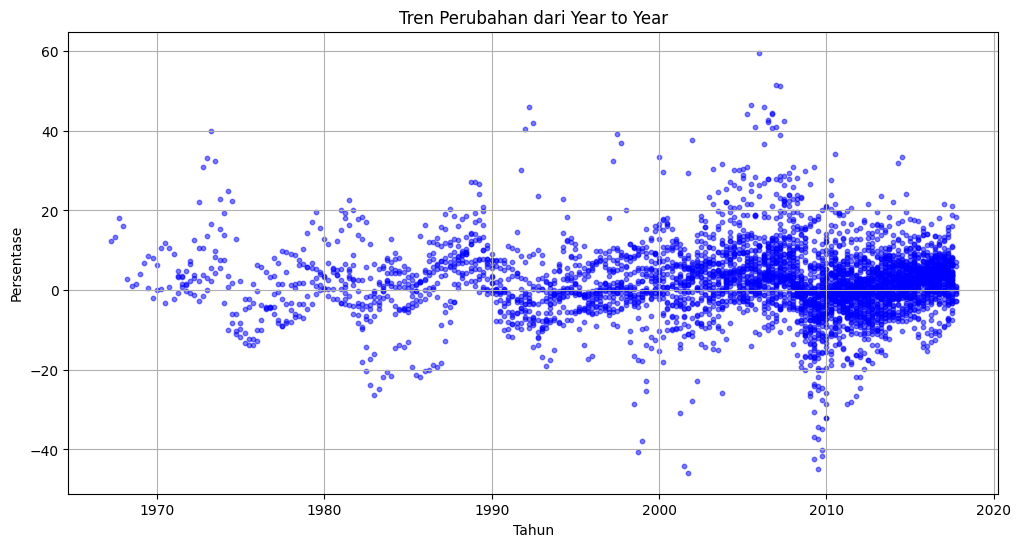

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.scatter(df_clean['date'], df_clean['price'], alpha=0.5, color='blue', s=10)

plt.title('Tren Perubahan dari Year to Year')
plt.xlabel('Tahun')
plt.ylabel('Persentase')
plt.grid(True)

plt.show()

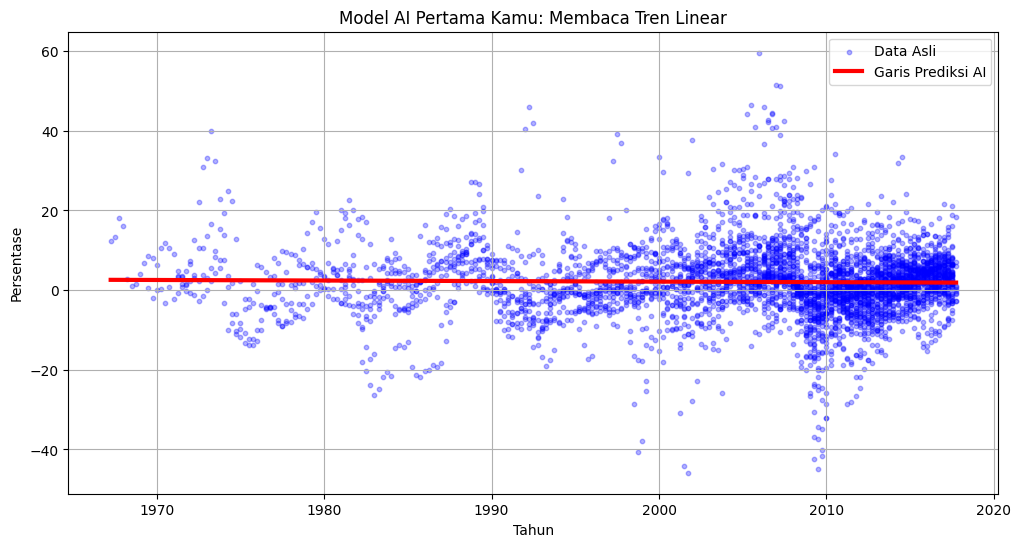

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_clean['date'].dt.year + df_clean['date'].dt.dayofyear / 365.25 #Masalah: Komputer gak paham tanggal seperti "1 Juli 2015". AI cuma paham angka desimal kontinu. Solusi: Kita ubah tanggal jadi angka desimal. Logikanya: dt.year itu tahunnya (misal: 2015). dt.dayofyear itu hari ke-berapa di tahun itu (misal: 1 Juli adalah hari ke-182). Hari ke-182 dibagi 365.25 hari (jumlah hari dalam setahun termasuk kabisat) hasilnya 0.5. Jadi, tanggal 1 Juli 2015 berubah menjadi angka 2015.5. Ini bikin AI tahu kalau data itu posisinya pas di pertengahan tahun!
X = X.values.reshape(-1,1)  # 1 di sini artinya kita mau ada satu kolom aja. -1 artinya kita suruh si Python hitung berapa banyak baris nantinya hasil dari proses sebelumnya. harus direshape karena data feature (fitur atau X) harus berbentuk matriks 2 dimensi yg punya baris dan kolom.
y = df_clean['price'].values # ini ngambil nilai dari kolom price dan ngubah datanya jadi array murni (buat jadi target (y) tebakan model nanti)

model = LinearRegression() #kita inisialisasi variabel 'model' buat dilatih pake model AI-Linear Regression
model.fit(X, y) #latihan si model dari data yg kita kasih

X_garis_prediksi = np.linspace(X.min(), X.max(), 100).reshape(-1,1) #np.linspace -> what's it for, is that to creating 100 numbers that starts from X.min, ends with X.max, then re-shape 'em into 2D matrix, yaitu banyak row dan 1 column
y_garis_prediksi = model.predict(X_garis_prediksi) # kasih tugas!

plt.figure(figsize=(12, 6)) # ukuran kertas tampilan (12 itu panjang dalam inchi, 6 itu lebar dalam inchi juga)
plt.scatter(X, y, alpha=0.3, color='blue', s=10, label='Data Asli') # alpha itu transparansi ya. 0 buat tembus pandang total hingga 1 buat padat/solid
plt.plot(X_garis_prediksi, y_garis_prediksi, color='red', linewidth=3, label='Garis Prediksi AI') #ini apa linewidth? lebar garis merahnya ya, hihi :)

plt.title('Model AI Pertama Kamu: Membaca Tren Linear')
plt.xlabel('Tahun')
plt.ylabel('Persentase')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Minta AI menebak kembali semua data masa lalu yang kita miliki
y_prediksi_total = model.predict(X)

# 2. Hitung skor matematika AI kita
mae = mean_absolute_error(y, y_prediksi_total)
r2 = r2_score(y, y_prediksi_total)

print("=== LAPORAN PERFORMA AI KAMU ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"R-squared Score (R2): {r2:.4f}")


=== LAPORAN PERFORMA AI KAMU ===
Mean Absolute Error (MAE): 6.19%
R-squared Score (R2): 0.0003


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Pecah data: 80% buat latihan (Train), 20% buat ujian murni (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Latih AI HANYA menggunakan Train Set
model_industri = LinearRegression()
model_industri.fit(X_train, y_train)

# 3. Uji AI menggunakan Test Set (Soal ujian baru yang BELUM PERNAH dilihat AI)
y_tebakan_ujian = model_industri.predict(X_test)

# 4. Hitung skor error yang jujur
mae_jujur = mean_absolute_error(y_test, y_tebakan_ujian)
print(f"Skor MAE Jujur (Standar Industri): {mae_jujur:.2f}%")
